In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Load the data from the CSV file
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
    low_memory=False,
)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1254453 non-null  str    
 1   Manufacturing Location Code          1255003 non-null  str    
 2   Intercompany                         1294962 non-null  str    
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  str    
 5   Customer Region                      1294859 non-null  str    
 6   Customer First Invoice Date          1294962 non-null  str    
 7   Top Customer Group                   1294962 non-null  str    
 8   Item Code                            1294907 non-null  str    
 9   Product family                       1294962 non-null  str    
 10  Product group                        1126302 non-null  str    
 11  Price las

In [3]:
df["Product family"].unique()

<StringArray>
['PF002', 'PF000', 'PF001', 'PC016', 'PC001', 'PC010']
Length: 6, dtype: str

In [4]:
df["Product group"].unique()

<StringArray>
[                  nan,               'PC026',               'SF002',
               'PC013',               'PC019',               'PC002',
               'PC014',               'PC029',               'PC004',
               'PC023',               'PC021',               'PC009',
               'PC010',               'PC001',               'PC017',
               'PC003',               'PC012',               'PC005',
               'PC022',               'PC016',               'PC011',
               'PC025',               'PC015',               'PC008',
               'PC007',               'PC018',               'PC030',
               'PC020',               'PC006',               'PC028',
               'SF001', '2016-11-02 00:00:00',               'PC024',
 '2018-09-01 00:00:00', '2020-05-22 00:00:00']
Length: 35, dtype: str

In [5]:
df["Item Code"].unique()

<StringArray>
[         '054501',          '034903',          '057280',          '309146',
          '343372',          '348716',          '352311',          '357269',
          '357314',          '357325',
 ...
          '20968A', '2-100-000-15524',          '414019',          '641817',
          '678018',     'B3-12100342',   '056-02387-000',   '205-60023-000',
          '056159',          '369267']
Length: 63020, dtype: str

In [6]:
df["CustomerID"].unique()

array([224224, 230494, 235861, ...,   1122, 285740, 247332],
      shape=(12214,))

In [7]:
minimum_frequency = 3

customer_frequency_table = (
    df["CustomerID"]
    .value_counts()
    .rename_axis("CustomerID")
    .reset_index(name="frequency")
    .sort_values(["frequency", "CustomerID"], ascending=[False, True])
    .reset_index(drop=True)
)

valid_customer_ids = customer_frequency_table.loc[
    customer_frequency_table["frequency"] >= minimum_frequency,
    "CustomerID",
]

original_row_count = len(df)
df_filtered = df[df["CustomerID"].isin(valid_customer_ids)].copy()
filtered_row_count = len(df_filtered)
removed_row_count = original_row_count - filtered_row_count
shrinkage_pct = (removed_row_count / original_row_count) * 100

print(f"CustomerID frequency table shape: {customer_frequency_table.shape}")
display(customer_frequency_table.head(20))
print(f"\nOriginal rows: {original_row_count:,}")
print(f"Rows after filtering CustomerID frequency >= {minimum_frequency}: {filtered_row_count:,}")
print(f"Removed rows: {removed_row_count:,}")
print(f"Dataset shrank by: {shrinkage_pct:.2f}%")
print(f"Unique CustomerID before: {df['CustomerID'].nunique():,}")
print(f"Unique CustomerID after: {df_filtered['CustomerID'].nunique():,}")


CustomerID frequency table shape: (12214, 2)


,CustomerID,frequency
0,19244,70230
1,18161,65059
2,224597,40748
3,294128,17866
4,18163,17723
5,24039,17377
6,23981,16751
7,25172,16498
8,19118,15115
9,21141,14995



Original rows: 1,294,962
Rows after filtering CustomerID frequency >= 3: 1,289,482
Removed rows: 5,480
Dataset shrank by: 0.42%
Unique CustomerID before: 12,214
Unique CustomerID after: 8,369


Number of unique invoices in the original dataset: 992,110


,Invoice #,frequency
0,15968559,318
1,15962475,275
2,15968138,250
3,15971797,233
4,15962346,221
5,15967624,200
6,15971644,191
7,15971978,190
8,15971820,185
9,15968657,184


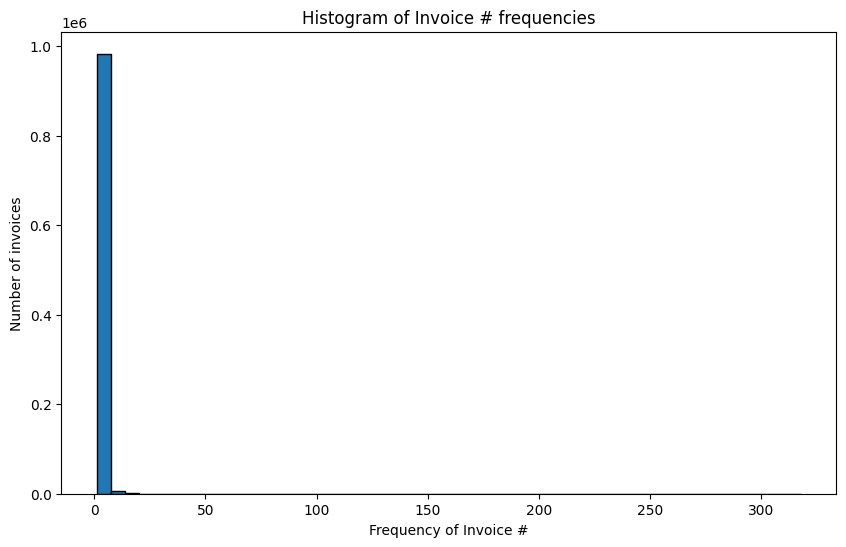

In [8]:
invoice_frequency_table = (
    df["Invoice #"]
    .value_counts()
    .rename_axis("Invoice #")
    .reset_index(name="frequency")
    .sort_values(["frequency", "Invoice #"], ascending=[False, True])
    .reset_index(drop=True)
)

invoice_count = df["Invoice #"].nunique()

print(f"Number of unique invoices in the original dataset: {invoice_count:,}")
display(invoice_frequency_table.head(20))

plt.figure(figsize=(10, 6))
plt.hist(invoice_frequency_table["frequency"], bins=50, edgecolor="black")
plt.xlabel("Frequency of Invoice #")
plt.ylabel("Number of invoices")
plt.title("Histogram of Invoice # frequencies")
plt.show()


In [9]:
from upselling_functions import build_product_after_last_purchase_matrix

product_after_last_matrix, product_index_lookup, customer_product_windows = build_product_after_last_purchase_matrix(
    df,
    min_customer_product_purchases=10,
    customer_col="CustomerID",
    product_col="Item Code",
    date_col="Invoice Date",
)

matrix_density = product_after_last_matrix.nnz / (
    product_after_last_matrix.shape[0] * product_after_last_matrix.shape[1]
)

print(f"Matrix shape: {product_after_last_matrix.shape}")
print(f"Non-zero entries: {product_after_last_matrix.nnz:,}")
print(f"Matrix density: {matrix_density:.6%}")
print(f"All products in matrix: {len(product_index_lookup):,}")
print(f"Products with at least one surviving customer-product pair: {customer_product_windows['Item Code'].nunique():,}")
print(f"Customer-product pairs kept: {len(customer_product_windows):,}")
print(f"Customers kept: {customer_product_windows['CustomerID'].nunique():,}")
display(product_index_lookup.head(20))
display(customer_product_windows.head(20))

matrix_coo = product_after_last_matrix.tocoo()

top_matrix_entries = pd.DataFrame(
    {
        "row_idx": matrix_coo.row,
        "col_idx": matrix_coo.col,
        "count": matrix_coo.data,
    }
)

top_matrix_entries = top_matrix_entries.sort_values(
    ["count", "row_idx", "col_idx"],
    ascending=[False, True, True],
).head(10)

lookup = product_index_lookup.rename(
    columns={"matrix_index": "matrix_idx", "Item Code": "item_code"}
)

top_matrix_entries = top_matrix_entries.merge(
    lookup,
    left_on="row_idx",
    right_on="matrix_idx",
    how="left",
).rename(columns={"item_code": "product_i"})

top_matrix_entries = top_matrix_entries.merge(
    lookup,
    left_on="col_idx",
    right_on="matrix_idx",
    how="left",
    suffixes=("", "_j"),
).rename(columns={"item_code": "product_j"})

print("Top 10 highest matrix elements:")
display(top_matrix_entries[["product_i", "product_j", "count"]])


Matrix shape: (63016, 63016)
Non-zero entries: 86,209
Matrix density: 0.002171%
All products in matrix: 63,016
Products with at least one surviving customer-product pair: 17,069
Customer-product pairs kept: 23,698
Customers kept: 3,199


,Item Code,matrix_index
0,F18293-000-AA,0
1,PAR540-.375,1
2,#5A0756390003,2
3,***AIR CHARGE,3
4,***EXTRA CHARGE,4
5,*/,5
6,*/MISC,6
7,*00010,7
8,*00020,8
9,*00030,9


,CustomerID,Item Code,purchase_count,first_purchase_date,last_purchase_date,product_idx
0,224224,054501,27,2018-01-31,2019-11-07,3098
3,223839,309146,17,2018-02-01,2020-05-06,19770
4,224307,343372,109,2018-01-11,2020-06-27,21417
5,224029,348716,108,2018-01-26,2020-06-30,21783
6,224029,352311,35,2018-01-09,2020-06-29,22037
7,224600,357269,56,2018-01-18,2020-05-28,22366
9,223638,357325,12,2018-08-22,2020-06-16,22369
12,223521,659288,67,2018-01-17,2020-06-30,30444
13,223521,661295,12,2018-04-11,2020-05-20,30879
19,31072,P170985,116,2018-01-02,2020-06-30,54559


Top 10 highest matrix elements:


,product_i,product_j,count
0,1708513,1700115,3
1,1708513,1705188,3
2,DEL449-YC553,DEL449-YC553-1,3
3,NEW-870-06183-B6,NEW-870-06074-B1,3
4,NEW-870-06183-B6,NEW-870-06162-B1,3
5,1001422,1001956,2
6,1001422,1002015,2
7,1001422,1002016,2
8,1001422,1002027,2
9,1001422,1002029,2
